In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
def load_and_profile_data(file_path):
    """Loads the dataset and performs an initial structural and quality audit."""
    print("=" * 60)
    print("1. LOADING DATA & STRUCTURAL AUDIT")
    print("=" * 60)

    # Load the dataset (handles .csv or .xlsx)
    if file_path.endswith(".xlsx"):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path)

    print(f"Dataset Shape: {df.shape[0]:,} rows | {df.shape[1]} columns\n")
    print("Column Data Types & Non-Null Counts:")
    print(df.info())
    return df

In [ ]:
def analyze_missing_data(df):
    """Identifies missing values and calculates completeness percentages."""
    print("\n" + "=" * 60)
    print("2. MISSING VALUES & COMPLETENESS AUDIT")
    print("=" * 60)

    missing_count = df.isnull().sum()
    missing_percent = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame(
        {"Missing Values": missing_count, "Percentage (%)": missing_percent}
    ).sort_values(by="Missing Values", ascending=False)

    print(missing_df[missing_df["Missing Values"] > 0])

    # Plot missing data
    plt.figure(figsize=(12, 5))
    sns.barplot(
        x=missing_df["Percentage (%)"][:10],
        y=missing_df.index[:10],
        hue=missing_df.index[:10],
        palette="Reds_r",
        legend=False,
    )
    plt.title("Top 10 Columns with Missing Data (Percentage)")
    plt.xlabel("Percentage Missing (%)")
    plt.tight_layout()
    plt.show()

In [ ]:
def analyze_cardinality(df, categorical_cols):
    """Profiles the unique value counts (cardinality) for categorical features."""
    print("\n" + "=" * 60)
    print("3. CARDINALITY & CATEGORICAL PROFILING")
    print("=" * 60)

    cardinality = []
    for col in categorical_cols:
        if col in df.columns:
            distinct_counts = df[col].nunique()
            cardinality.append({"Column": col, "Unique Values": distinct_counts})

    card_df = pd.DataFrame(cardinality).sort_values(
        by="Unique Values", ascending=False
    )
    print(card_df.to_string(index=False))

In [ ]:
def analyze_timeline(df, date_cols):
    """Audits date logic, ranges, and consistency across timeline metrics."""
    print("\n" + "=" * 60)
    print("4. TIMELINE & DATE LOGIC AUDIT")
    print("=" * 60)

    # Convert to datetime safely
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    # Check date ranges
    for col in date_cols:
        if col in df.columns:
            print(f"Column '{col}' Range: {df[col].min().date()} to {df[col].max().date()}")

    # Logic Check: Date received should not be before Date submitted
    if all(c in df.columns for c in date_cols):
        logic_errors = df[df[date_cols[1]] < df[date_cols[0]]]
        print(f"\nTimeline Logic Errors (Received before Submitted): {len(logic_errors)} rows")

In [ ]:
def generate_distribution_plots(df):
    """Generates visual distribution plots for key operational categories."""
    print("\n" + "=" * 60)
    print("5. GENERATING VISUAL DISTRIBUTIONS")
    print("=" * 60)

    # 1. Product Distribution
    if "Product" in df.columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(
            data=df,
            y="Product",
            order=df["Product"].value_counts().index,
            hue="Product",
            palette="viridis",
            legend=False,
        )
        plt.title("Distribution of Complaints by Product Type")
        plt.xlabel("Complaint Count")
        plt.tight_layout()
        plt.show()

    # 2. Timely Response Distribution
    if "Timely response" in df.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x="Timely response", hue="Timely response", palette="coolwarm")
        plt.title("Is Company Response Timely? (SLA Check)")
        plt.ylabel("Complaint Count")
        plt.tight_layout()
        plt.show()

1. LOADING DATA & STRUCTURAL AUDIT
Dataset Shape: 62,516 rows | 12 columns

Column Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62516 non-null  int64         
 1   Submitted via                 62516 non-null  object        
 2   Date submitted                62516 non-null  datetime64[ns]
 3   Date received                 62516 non-null  datetime64[ns]
 4   State                         62516 non-null  object        
 5   Product                       62516 non-null  object        
 6   Sub-product                   62509 non-null  object        
 7   Issue                         62516 non-null  object        
 8   Sub-issue                     51658 non-null  object        
 9   Company public response       60341 non-null  o

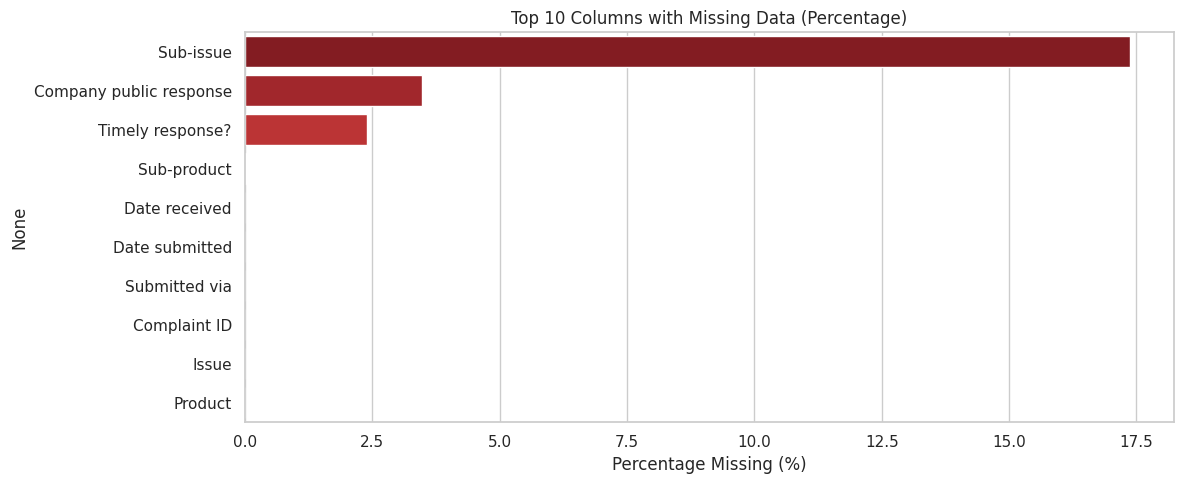


3. CARDINALITY & CATEGORICAL PROFILING
                      Column  Unique Values
                   Sub-issue            158
                       Issue             76
                       State             51
                 Sub-product             46
                     Product              9
               Submitted via              7
     Company public response              6
Company response to consumer              5

4. TIMELINE & DATE LOGIC AUDIT
Column 'Date submitted' Range: 2017-05-01 to 2023-08-28
Column 'Date received' Range: 2017-05-01 to 2023-08-28

Timeline Logic Errors (Received before Submitted): 0 rows

5. GENERATING VISUAL DISTRIBUTIONS


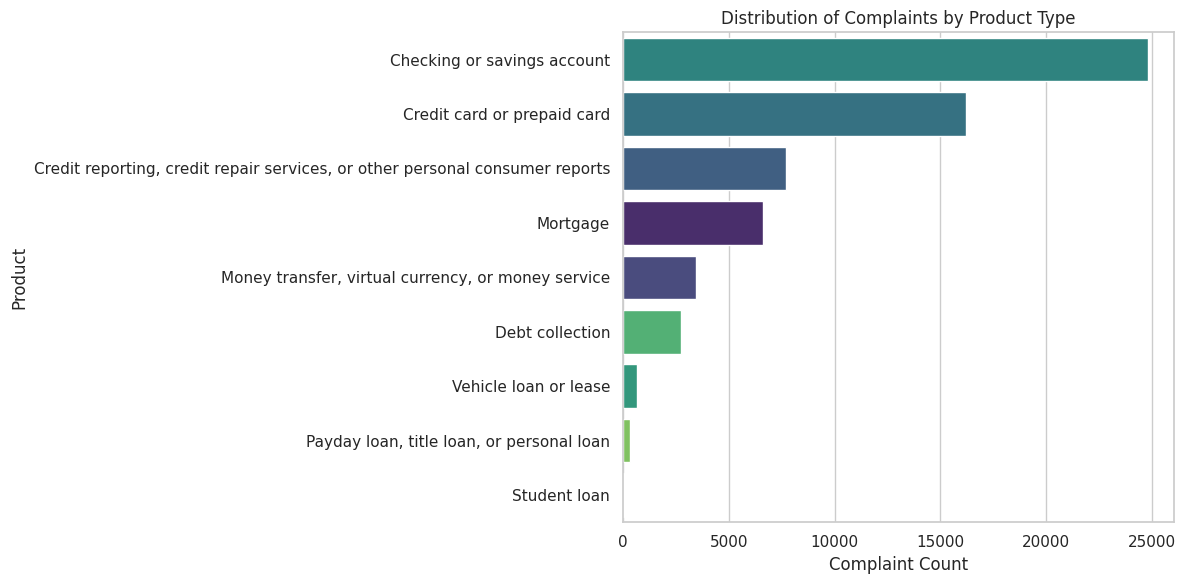


EDA COMPLETE: Review the printed statistics and closed plots.


In [20]:
if __name__ == "__main__":
    FILE_NAME = "/content/New Microsoft Excel Worksheet.xlsx"

    if not os.path.exists(FILE_NAME):
        print(f"Error: Could not find file '{FILE_NAME}' in your current folder.")
        print("Please move your file here or update the FILE_NAME variable in the script.")
    else:
        raw_df = load_and_profile_data(FILE_NAME)

        target_categories = [
            "Submitted via",
            "State",
            "Product",
            "Sub-product",
            "Issue",
            "Sub-issue",
            "Company public response",
            "Company response to consumer",
            "Timely response",
        ]

        target_dates = ["Date submitted", "Date received"]

        analyze_missing_data(raw_df)
        analyze_cardinality(raw_df, target_categories)
        analyze_timeline(raw_df, target_dates)
        generate_distribution_plots(raw_df)
